<div style="background: linear-gradient(120deg, #1a3a5c 0%, #2d6a9f 60%, #4a9eda 100%); padding: 28px 36px; border-radius: 14px; display: flex; align-items: center; gap: 28px; box-shadow: 0 4px 18px rgba(0,0,0,0.18);">
    <img src='Figures/iteso.jpg' style="height: 110px; border-radius: 8px; background: white; padding: 6px; flex-shrink: 0; box-shadow: 0 2px 8px rgba(0,0,0,0.2);"/>
    <div style="border-left: 2px solid rgba(255,255,255,0.4); padding-left: 28px;">
        <h1 style="margin: 0 0 8px 0; color: white; font-size: 1.5em; line-height: 1.3;">Ingeniería y Ciencia de Datos</h1>
        <h3 style="margin: 0 0 8px 0; color: white; font-size: 1.5em; line-height: 1.3;">Laboratorio de Procesamiento de Datos</h3>
        <h3 style="margin: 0; color: rgba(255,255,255,0.8); font-weight: normal; font-size: 1.05em;">Módulo 1: Repaso general del Modulo I</h3>
    </div>
</div>



**En esta sesión** repasamos los temas del Módulo I antes del examen:

1. Extracción de datos de diferentes fuentes (texto, CSV, Excel, Parquet, JSON, XML, HTML, imágenes y SHP).
2. Clasificación de tipos de datos.
3. Datos faltantes: diagnóstico, mecanismos e imputación.
4. Datos atípicos: IQR, Z‑score y Z‑score modificado.
5. **Una Práctica antes del examen** 

> Todo proyecto de datos empieza con dos preguntas:

- **¿cómo leo los datos correctamente?**
- **¿qué representa cada columna?**

> Si fallamos en cualquiera de las dos, todo el análisis posterior hereda el error.

### Flujo general del Módulo I

```mermaid
flowchart LR
    A[Fuente de datos: TXT / CSV / Excel / Parquet / JSON / XML / HTML / Imagen / SHP] --> B[Extracción con Python y pandas]
    B --> C[Inspección: shape, dtypes, head, nunique]
    C --> D[Clasificación de variables]
    D --> E[Diagnóstico de faltantes]
    E --> F[Detección de atípicos]
    F --> G[Datos listos para análisis o modelado]
```

In [1]:
# Configuración común
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dir_base = Path.cwd()
ruta = dir_base / "Data"


In [ ]:
print(ruta, ruta.exists())


# 1. Extracción de datos de diferentes fuentes

## Resumen de formatos

| Formato | Estructura | Lectura en Python | Parámetros / detalles clave | Consideraciones|
|---|---|---|---|---|
| **Texto (`.txt`)** | Libre, línea por línea | `open(ruta, encoding="utf-8")` dentro de `with` | `.read()`, `.readlines()`, `for linea in f` | Codificación, saltos de línea, encabezados que no son datos |
| **CSV** | Tabla plana | `pd.read_csv` | `sep`, `encoding`, `header`, `names`, `na_values`, `parse_dates`, `skipinitialspace` | Separador `;`, columna `Unnamed: 0`, `?` como faltante |
| **Excel** | Libro con hojas | `pd.read_excel` / `pd.ExcelWriter` | `sheet_name=None` → `dict` de hojas, `skiprows` | Encabezados combinados, varias tablas por hoja |
| **Parquet** | Columnar, binario, con esquema | `pd.read_parquet` / `to_parquet` | `columns=`, `filters=`, `partition_cols=` | Requiere `pyarrow`; columnas de partición en nombres de carpeta |
| **JSON** | Jerárquico (llave: valor) | `json.load`, `pd.json_normalize` | `record_path`, `meta`, `sep` | Listas anidadas, llaves que no existen en todos los registros |
| **XML** | Árbol de etiquetas y atributos | `xml.etree.ElementTree`, `pd.read_xml` | `xpath`, `namespaces`, `.find`, `.findall`, `.get` | *Namespaces*, información en nodos padre, ceros iniciales perdidos |
| **HTML** | Árbol de etiquetas | `BeautifulSoup`, `pd.read_html` | `find_all("a")`, `.get("href")`, `StringIO` | Tablas con `$` y `,`, contenido dinámico (JavaScript) |
| **Imagen** | Matriz de píxeles | `PIL.Image.open` → `np.array` | `shape = (alto, ancho, canales)`, `dtype=uint8` | Modo `RGB` vs `RGBA` vs `L` |
| **Shapefile** | Geometrías + atributos | `geopandas.read_file` | `.shp`, `.shx`, `.dbf`, `.prj`, `to_crs` | Faltan archivos compañeros, sistemas de coordenadas distintos |

##  Recorrido rápido por los formatos
Leamos un archivo de cada tipo de la carpeta `Data` y construyamos una tabla resumen de lo que obtuvimos.

In [ ]:
# Texto plano
with open(ruta / "texto_3.txt", encoding="utf-8") as f:
    texto = f.read()
palabras = re.findall("[a-záéíóúüñ]+", texto.lower())
print(f"Caracteres: {len(texto)} | Palabras: {len(palabras)} | Únicas: {len(set(palabras))}")

# CSV y Parquet con el mismo contenido
df_csv = pd.read_csv(ruta / "productos.csv")
df_parquet = pd.read_parquet(ruta / "productos.parquet")

# Excel: todas las hojas de una vez
hojas = pd.read_excel(ruta / "reporte_pobreza.xlsx", sheet_name=None)
print("Hojas del Excel:", list(hojas))

# XML
df_xml = pd.read_xml(ruta / "tabla_1.xml")

# JSON anidado: un renglón por canción
with open(ruta / "metallica.json", encoding="utf-8") as f:
    albumes = json.load(f)
df_json = pd.json_normalize([a["album"] for a in albumes], record_path=["tracks", "track"],
                            meta=["name"], meta_prefix="album_")

resumen = pd.DataFrame({
    "archivo": ["productos.csv", "productos.parquet", "tabla_1.xml", "metallica.json"],
    "filas": [len(df_csv), len(df_parquet), len(df_xml), len(df_json)],
    "columnas": [df_csv.shape[1], df_parquet.shape[1], df_xml.shape[1], df_json.shape[1]],
})
resumen

In [ ]:
# HTML e imagen
from bs4 import BeautifulSoup
from PIL import Image

with open(ruta / "ejemplo.html", encoding="utf-8") as f:
    soup = BeautifulSoup(f.read(), "html.parser")
print("title:", soup.title.string)
print("enlaces:", [(a.get_text(strip=True), a.get("href")) for a in soup.find_all("a")])

img = np.array(Image.open(ruta / "butterfly.jpg"))
print("imagen:", img.shape, img.dtype, "| media por canal:", img.reshape(-1, img.shape[-1]).mean(axis=0).round(1))

**Preguntas rápidas de repaso**

- ¿Por qué un archivo Parquet pesa menos que su CSV equivalente y además conserva el tipo `datetime`?
- ¿Qué devuelve `pd.read_excel(..., sheet_name=None)`?
- En un JSON anidado, ¿para qué sirven `record_path` y `meta`?
- En un XML, ¿qué pasa con la información que está en un **atributo del nodo padre** cuando usas `pd.read_xml`?

# 2. Clasificación de tipos de datos


```mermaid
flowchart TD
    V[Variable] --> Q[Cualitativa / Categórica]
    V --> N[Cuantitativa / Numérica]
    Q --> NO[Nominal: sin orden]
    Q --> OR[Ordinal: con orden]
    NO --> BI[Binaria: 2 niveles]
    N --> DI[Discreta: se cuenta]
    N --> CO[Continua: se mide]
```

- El **`dtype` no es el tipo de variable**
- Ordinales → `pd.Categorical(..., categories=[...], ordered=True)`.
- Binarias → `map({"yes": 1, "no": 0})`, conservando faltantes con `Int64`.
- Variables **cíclicas** (mes, hora, día de la semana) no deben tratarse como números lineales.
- **Valores centinela** (`-1`, `0`, `999`, `99999`, `"?"`, `"unknown"`) suelen codificar ausencias.
- **Alta cardinalidad** (IDs, zonas, nombres) → agrupar categorías raras o no usar directamente.

# 3. Datos atípicos

| Método | Regla | Supuestos | Ventaja | Limitación |
|---|---|---|---|---|
| **IQR** | $x < Q_1 - 1.5\,IQR$ o $x > Q_3 + 1.5\,IQR$ | Ninguno fuerte | Robusto, base del boxplot | Marca muchos puntos en distribuciones asimétricas |
| **Desviación estándar / Z‑score** | $\lvert z \rvert = \lvert (x - \bar{x}) / s \rvert > 3$ | Distribución ≈ normal | Fácil de interpretar | Media y $s$ se inflan con los atípicos (enmascaramiento) |
| **Z‑score modificado** | $\lvert 0.6745\,(x - \tilde{x}) / MAD \rvert > 3.5$ | Ninguno fuerte | Usa mediana y MAD: robusto | Si MAD = 0 no se puede calcular |

**Antes de eliminar un atípico pregúntate:** ¿es un **error** de captura (un cero de más, unidades distintas) o un **valor real** poco frecuente? En variables muy asimétricas (ingresos, periodos, emisiones) conviene aplicar `log10` antes de detectar.

# 4. Práctica de Laboratorio antes del Examen 


## Ejercicio 1: Extracción multi‑fuente

**Texto plano: `niebla_unamuno.txt`**

El archivo es la novela *Niebla* descargada de Project Gutenberg. Incluye un encabezado y un pie de licencia en inglés que **no** forman parte de la obra.

1. Lee el archivo con `open(..., encoding="utf-8")` dentro de un `with`. Conserva **solo** el texto entre las marcas `*** START OF ...` y `*** END OF ...`. Reporta el número de caracteres y de líneas antes y después del recorte.
2. Los capítulos inician con una línea que contiene solo un número romano (`I`, `II`, …). Cuenta cuántos capítulos tiene la novela.
3. Normaliza el texto (minúsculas, solo letras incluyendo acentos y `ñ`) con un patron ('[a-záéíóúüñ]+') y construye un `DataFrame` con las **15 palabras más frecuentes** de longitud ≥ 5. ¿Cuántas veces aparecen `augusto` y `eugenia`?
4. Guarda el resultado como CSV en una carpeta `salida` en la carpeta `Data`.


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
datos_repaso = os.path.join(ruta, 'Datos_repaso')
salida = os.path.join(datos_repaso, 'salida')

In [ ]:
# 1 Lectura y recorte 
with open(os.path.join(datos_repaso, "niebla_unamuno.txt"), encoding="utf-8") as f:
    texto = f.read()

marca_ini = re.search(r"\*\*\* START OF .*?\*\*\*", texto)
marca_fin = re.search(r"\*\*\* END OF .*?\*\*\*", texto)
texto_obra = texto[marca_ini.end():marca_fin.start()].strip()

print(f"Antes   -> caracteres: {len(texto)} | líneas: {len(texto.splitlines())}")
print(f"Después -> caracteres: {len(texto_obra)} | líneas: {len(texto_obra.splitlines())}")

Antes   -> caracteres: 339189 | líneas: 8708
Después -> caracteres: 319674 | líneas: 8319


In [ ]:
# 2 Capítulos
lineas = texto_obra.splitlines()
capitulos = [l.strip() for l in lineas if re.fullmatch(r"[IVXLCDM]+", l.strip())]
print("Número de capítulos:", len(capitulos))

Número de capítulos: 33


In [ ]:
# 3 Normalización y 15 palabras más frecuentes 
palabras = re.findall(r"[a-záéíóúüñ]+", texto_obra.lower())
palabras_5 = [p for p in palabras if len(p) >= 5]

top15 = pd.DataFrame(Counter(palabras_5).most_common(15), columns=["palabra", "frecuencia"])
display(top15)

conteo = Counter(palabras)
print("augusto:", conteo["augusto"], "| eugenia:", conteo["eugenia"])

,palabra,frecuencia
0,usted,376
1,augusto,372
2,eugenia,233
3,mujer,188
4,hombre,150
5,ahora,136
6,cuando,132
7,porque,113
8,mismo,106
9,sobre,94


augusto: 372 | eugenia: 233


In [ ]:
# 4 Guardar el resultado
os.makedirs(salida, exist_ok=True)
top15.to_csv(os.path.join(salida, "top15_palabras_niebla.csv"), index=False, encoding="utf-8")
print(os.listdir(salida))

['top15_palabras_niebla.csv']


##  Ejercicio 2: Clasificación de tipos de datos

Usa `taxis_nyc.csv` (viajes de taxi en Nueva York, marzo de 2019).

1. Carga el archivo. Muestra `shape`, `dtypes` y `nunique()`. Separa las columnas en `numericas` y `no_numericas` con `select_dtypes`.
2. Clasifica los tipos de variables en una tabla: `pickup`, `passengers`, `distance`, `fare`, `tip`, `tolls`, `color`, `payment`, `pickup_zone`, `pickup_borough` y la variable derivada `duracion_min = (dropoff - pickup)` en minutos.
3. ¿Hay viajes con **0 pasajeros**, `distance == 0` o `duracion_min <= 0`?
4. Crea una columna `es_amarillo` (1/0) y `pago_tarjeta` (1/0).



In [8]:

taxis = pd.read_csv(os.path.join(datos_repaso, "taxis_nyc.csv"), parse_dates=["pickup", "dropoff"])
print(taxis.shape)


(6433, 14)


In [ ]:
# 1 shape, dtypes, nunique y separación
print("shape:", taxis.shape)
display(pd.DataFrame({"dtype": taxis.dtypes, "nunique": taxis.nunique()}))

numericas = taxis.select_dtypes(include="number").columns.tolist()
no_numericas = taxis.select_dtypes(exclude="number").columns.tolist()
print("numericas:", numericas)
print("no_numericas:", no_numericas)

shape: (6433, 14)


,dtype,nunique
pickup,datetime64[us],6414
dropoff,datetime64[us],6425
passengers,int64,7
distance,float64,1079
fare,float64,220
tip,float64,489
tolls,float64,16
total,float64,898
color,str,2
payment,str,2


numericas: ['passengers', 'distance', 'fare', 'tip', 'tolls', 'total']
no_numericas: ['pickup', 'dropoff', 'color', 'payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']


In [ ]:
# 2 Variable derivada y tabla de clasificación
taxis["duracion_min"] = (taxis["dropoff"] - taxis["pickup"]).dt.total_seconds() / 60

clasificacion = pd.DataFrame({
    "variable": ["pickup", "passengers", "distance", "fare", "tip", "tolls",
                 "color", "payment", "pickup_zone", "pickup_borough", "duracion_min"],
    "tipo": ["Cuantitativa", "Cuantitativa", "Cuantitativa", "Cuantitativa", "Cuantitativa", "Cuantitativa",
             "Cualitativa", "Cualitativa", "Cualitativa", "Cualitativa", "Cuantitativa"],
    "subtipo": ["Continua (temporal)", "Discreta", "Continua", "Continua", "Continua", "Continua",
                "Nominal (binaria)", "Nominal (binaria)", "Nominal", "Nominal", "Continua"],
    "nota": ["fecha-hora; hora y día de la semana son cíclicas",
             "se cuenta",
             "se mide (millas)",
             "se mide (dólares)",
             "se mide (dólares)",
             "se mide (dólares); muchos ceros",
             "yellow / green",
             "credit card / cash",
             "alta cardinalidad",
             "pocos niveles",
             "derivada: dropoff - pickup, en minutos"],
})
clasificacion.insert(1, "dtype", [str(taxis[v].dtype) for v in clasificacion["variable"]])
clasificacion

,variable,dtype,tipo,subtipo,nota
0,pickup,datetime64[us],Cuantitativa,Continua (temporal),fecha-hora; hora y día de la semana son cíclicas
1,passengers,int64,Cuantitativa,Discreta,se cuenta
2,distance,float64,Cuantitativa,Continua,se mide (millas)
3,fare,float64,Cuantitativa,Continua,se mide (dólares)
4,tip,float64,Cuantitativa,Continua,se mide (dólares)
5,tolls,float64,Cuantitativa,Continua,se mide (dólares); muchos ceros
6,color,str,Cualitativa,Nominal (binaria),yellow / green
7,payment,str,Cualitativa,Nominal (binaria),credit card / cash
8,pickup_zone,str,Cualitativa,Nominal,alta cardinalidad
9,pickup_borough,str,Cualitativa,Nominal,pocos niveles


In [ ]:
# 3 Viajes con valores sospechosos
pd.DataFrame({
    "condición": ["passengers == 0", "distance == 0", "duracion_min <= 0"],
    "viajes": [(taxis["passengers"] == 0).sum(),
               (taxis["distance"] == 0).sum(),
               (taxis["duracion_min"] <= 0).sum()],
})

,condición,viajes
0,passengers == 0,96
1,distance == 0,51
2,duracion_min <= 0,6


In [ ]:
# 4 Variables binarias 
taxis["es_amarillo"] = taxis["color"].map({"yellow": 1, "green": 0}).astype("Int64")
taxis["pago_tarjeta"] = taxis["payment"].map({"credit card": 1, "cash": 0}).astype("Int64")

taxis[["color", "es_amarillo", "payment", "pago_tarjeta"]].head(10)

,color,es_amarillo,payment,pago_tarjeta
0,yellow,1,credit card,1
1,yellow,1,cash,0
2,yellow,1,credit card,1
3,yellow,1,credit card,1
4,yellow,1,credit card,1
5,yellow,1,credit card,1
6,yellow,1,credit card,1
7,yellow,1,NaN,<NA>
8,yellow,1,credit card,1
9,yellow,1,credit card,1



## Ejercicio 3: Datos faltantes y atípicos

Usa `co2_owid.csv`: emisiones de CO₂, CO₂ per cápita, población y PIB por país y año desde 1950.

**Faltantes**

1. Calcula conteo y % de faltantes por columna.
2. Filtra los renglones donde `iso_code` es faltante y revisa `country`. ¿Qué puedes cocnluir de este análisis?

**Atípicos**

3. Para **2020**, detecta atípicos de `co2_per_capita` con IQR. Lista los países y muestra un boxplot.

In [13]:
co2 = pd.read_csv(os.path.join(datos_repaso, "co2_owid.csv"))
display(pd.DataFrame({"faltantes": co2.isna().sum(), "%": (co2.isna().mean() * 100).round(2)}))


,faltantes,%
country,0,0.00
year,0,0.00
iso_code,2634,13.87
population,1809,9.53
gdp,7512,39.57
co2,1437,7.57
co2_per_capita,2491,13.12


In [14]:
# 2. Renglones con iso_code faltante
sin_iso = co2[co2["iso_code"].isna()]
print("Renglones sin iso_code:", len(sin_iso))
paises_sin_iso = sorted(sin_iso["country"].unique())
print(len(paises_sin_iso), "entidades:")
print(paises_sin_iso)

Renglones sin iso_code: 2634
36 entidades:
['Africa', 'Africa (GCP)', 'Asia', 'Asia (GCP)', 'Asia (excl. China and India)', 'Central America (GCP)', 'Europe', 'Europe (GCP)', 'Europe (excl. EU-27)', 'Europe (excl. EU-28)', 'European Union (27)', 'European Union (28)', 'High-income countries', 'International aviation', 'International shipping', 'Kosovo', 'Kuwaiti Oil Fires', 'Kuwaiti Oil Fires (GCP)', 'Least developed countries (Jones et al.)', 'Low-income countries', 'Lower-middle-income countries', 'Middle East (GCP)', 'Non-OECD (GCP)', 'North America', 'North America (GCP)', 'North America (excl. USA)', 'OECD (GCP)', 'OECD (Jones et al.)', 'Oceania', 'Oceania (GCP)', 'Ryukyu Islands', 'Ryukyu Islands (GCP)', 'South America', 'South America (GCP)', 'Upper-middle-income countries', 'World']


**Conclusión:** los renglones sin `iso_code` no son países. Son agregados regionales. Es un faltante estructural, no un error de captura, así que no se imputa, para analizar países se deben excluir estos renglones (`iso_code` no nulo), de lo contrario algunos como `World` se mezclarían con países en comparaciones y detección de atípicos.

Q1 = 0.917 | Q3 = 5.715 | IQR = 4.798 | límites: [-6.280, 12.912]
Países atípicos: 15


,country,co2_per_capita
0,Qatar,36.145
1,Bahrain,25.238
2,Brunei,24.937
3,Trinidad and Tobago,23.661
4,United Arab Emirates,22.783
5,Saudi Arabia,21.089
6,Kuwait,20.477
7,New Caledonia,17.978
8,Sint Maarten (Dutch part),15.897
9,Oman,15.886


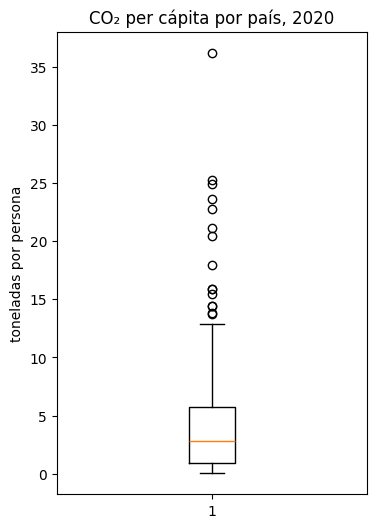

In [ ]:
# 3 Atípicos
co2_2020 = co2[(co2["year"] == 2020) & co2["iso_code"].notna()].dropna(subset=["co2_per_capita"])

q1 = co2_2020["co2_per_capita"].quantile(0.25)
q3 = co2_2020["co2_per_capita"].quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr
print(f"Q1 = {q1:.3f} | Q3 = {q3:.3f} | IQR = {iqr:.3f} | límites: [{lim_inf:.3f}, {lim_sup:.3f}]")

atipicos = co2_2020[(co2_2020["co2_per_capita"] < lim_inf) | (co2_2020["co2_per_capita"] > lim_sup)]
atipicos = atipicos.sort_values("co2_per_capita", ascending=False)
print("Países atípicos:", len(atipicos))
display(atipicos[["country", "co2_per_capita"]].reset_index(drop=True))

plt.figure(figsize=(4, 6))
plt.boxplot(co2_2020["co2_per_capita"])
plt.title("CO₂ per cápita por país, 2020")
plt.ylabel("toneladas por persona")
plt.show()

##### (1pto para Modulo I antes de terminar el día) 
###### enviar a: gdesirena@iteso.mx